# Pre-Experiment: online vs. offline in algorithm selection

In this notebook, we compare the selection accuracy of online and offline methods.

online method: AVG estimator using A/B testing data.

offline method: IPS estimator using offline data, which logged from algorithm A.

In [7]:
import os
import contextlib
import warnings

import numpy as np
import pandas as pd
from tqdm import tqdm
import joblib
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

from dataset import SyntheticDataset
from estimation import run_experiment
from utils import evaluate_performance

warnings.filterwarnings('ignore')

## Experiment

In [ ]:
# experiment configuration
n_sims = 10000 # number of simulation runs
n0_data = 500 # sample size logged from policy 0 (algorithm A)
n1_data = 500 # sample size logged from policy 1 (algorithm B)
n_actions = 30 # number of actions
x_dim = 5 # context feature dimension
a_dim = 5 # action feature dimension
n_all_users = 100000 # number of all users
reward_std = 1.0 # level of noise on the reward
reward_type = "continuous" # binary or continuous

# policy params
# - policy_kind: the kind of conditioned action distribution
# - mu_rate: the peak position rate of the action distribution
# - sigma: the length of tail
policy_0_params = {"policy_kind": "sorted_normal", "mu_rate": 0.5, "sigma": 8.0}
policy_1_params_list = [
    {"policy_kind": "sorted_normal", "mu_rate": 0.50, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.55, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.60, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.65, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.70, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.75, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.80, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.85, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.90, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.95, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 1.00, "sigma": 8.0},
]

In [3]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [4]:
def estimate(policy_0_params, policy_1_params):
    dataset = SyntheticDataset(
        n_actions=n_actions, x_dim=x_dim, a_dim=a_dim,
        n_all_users=n_all_users, reward_type=reward_type, reward_std=reward_std,
        random_state=os.getpid()
    )

    true_value_of_pi_0 = dataset.calc_policy_value(policy_params=policy_0_params)
    true_value_of_pi_1 = dataset.calc_policy_value(policy_params=policy_1_params)
    is_pi_1_better = np.int32(true_value_of_pi_0 < true_value_of_pi_1)
    is_pi_1_better = is_pi_1_better - (1 - is_pi_1_better)

    estimated_pi_0_value_list = []
    estimated_pi_1_value_list = []
    estimated_pi_m_D_1_value_list = []
    estimated_pi_m_D_0_value_list = []
    estimated_comparison_list = []
    estimated_p_value_list = []

    for _ in range(n_sims):
        D_E_0 = dataset.generate_dataset(
            n_data=n0_data,
            logging_policy_params=policy_0_params,
            evaluation_policy_params=policy_1_params
        )
        D_E_1 = dataset.generate_dataset(
            n_data=n1_data,
            logging_policy_params=policy_1_params,
            evaluation_policy_params=policy_0_params
        )

        values_of_pi_1, values_of_pi_m_D_1, values_of_pi_m_D_0, values_of_pi_0, comparison, p_value = run_experiment([D_E_0, D_E_1])
        estimated_pi_1_value_list.append(values_of_pi_1)
        estimated_pi_m_D_1_value_list.append(values_of_pi_m_D_1)
        estimated_pi_m_D_0_value_list.append(values_of_pi_m_D_0)
        estimated_pi_0_value_list.append(values_of_pi_0)
        estimated_comparison_list.append(comparison)
        estimated_p_value_list.append(p_value)

    result_df = (
        pd.concat([
            pd.DataFrame(estimated_pi_1_value_list).stack(),
            pd.DataFrame(estimated_pi_m_D_1_value_list).stack(),
            pd.DataFrame(estimated_pi_m_D_0_value_list).stack(),
            pd.DataFrame(estimated_pi_0_value_list).stack(),
            pd.DataFrame(estimated_comparison_list).stack(),
            pd.DataFrame(estimated_p_value_list).stack(),
        ], axis=1)
        .reset_index(1)
        .rename(columns={
            "level_1": "est",
            0: "pi_1_value", 1: "pi_m_D_1_value", 2: "pi_m_D_0_value",
            3: "pi_0_value", 4: "selection", 5: "p_value"
        })
    )
    result_df["mu_rate_1"] = policy_1_params["mu_rate"]
    result_df["mu_rate_0"] = policy_0_params["mu_rate"]
    result_df["true_pi_1_value"] = true_value_of_pi_1
    result_df["true_pi_0_value"] = true_value_of_pi_0
    result_df["selection"] *= is_pi_1_better
    result_df["selection"] = result_df["selection"] == 1

    return result_df

In [5]:
with tqdm_joblib(tqdm(total=len(policy_1_params_list))):
    result_df_list = Parallel(n_jobs=-1, verbose=0)(
        [delayed(estimate)(policy_0_params, policy_1_params) for policy_1_params in policy_1_params_list]
    )

result_df = pd.concat(result_df_list).reset_index(level=0)
result_df

  0%|          | 0/11 [00:00<?, ?it/s]/Users/hdymacuser/workspace/kdd2026-mid/notebooks/utils.py:71: RuntimeWarning: invalid value encountered in scalar divide
  t_stat = np.abs(mean_a - mean_b) / se
/Users/hdymacuser/workspace/kdd2026-mid/notebooks/utils.py:75: RuntimeWarning: invalid value encountered in scalar divide
  df = df_num / df_den
100%|██████████| 11/11 [01:16<00:00,  6.96s/it]


,index,est,pi_1_value,pi_m_D_1_value,pi_m_D_0_value,pi_0_value,selection,p_value,mu_rate_1,mu_rate_0,true_pi_1_value,true_pi_0_value
0,0,AVG,0.058799,0.000000,0.000000,0.045906,False,0.831375,0.5,0.5,0.003951,0.003951
1,0,IPS,0.045906,0.000000,0.000000,0.045906,True,1.000000,0.5,0.5,0.003951,0.003951
2,0,AVG_IPS,0.058799,0.058799,0.045906,0.045906,True,NaN,0.5,0.5,0.003951,0.003951
3,0,MIN,0.058799,0.058799,0.045906,0.045906,True,NaN,0.5,0.5,0.003951,0.003951
4,0,MID,0.058799,0.058799,0.045906,0.045906,True,NaN,0.5,0.5,0.003951,0.003951


## Analyze

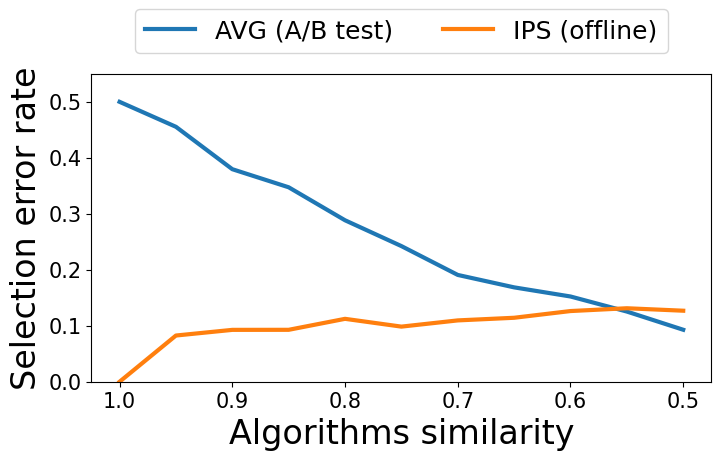

In [13]:
plt.rcParams["font.size"] = 15
plt.figure(figsize=(8, 4))
for est in ["AVG", "IPS"]:
    mask_est = result_df["est"] == est
    result_dict = {
        "accuracy": [],
        "squared_bias": [],
        "variance": [],
        "MSE": [],
    }
    
    mu_rate_1_list = [params["mu_rate"] for params in policy_1_params_list]
    for mu_rate_1 in mu_rate_1_list:
        mask_mu_rate_1 = result_df["mu_rate_1"] == mu_rate_1
        mask = mask_est & mask_mu_rate_1
        performance = evaluate_performance(result_df[mask].copy())
        
        result_dict["accuracy"].append(performance["accuracy"])
        result_dict["squared_bias"].append(performance["squared_bias"])
        result_dict["variance"].append(performance["variance"])
        result_dict["MSE"].append(performance["MSE"])
    
    est_name = "AVG" if est == "AB_test" else "IPS"
    plt.plot(mu_rate_1_list, 1-np.array(result_dict["accuracy"]), label=f"{est_name}", linewidth=3)
    x = ["0.5", "0.6", "0.7", "0.8", "0.9", "1.0"]
    plt.xticks(mu_rate_1_list[::2], x[::-1])
    plt.ylim(0.0, 0.55)
    plt.xlabel("Algorithms similarity", fontsize=24)
    plt.ylabel("Selection error rate", fontsize=24)

plt.legend(["AVG (A/B test)", "IPS (offline)"], ncol=2, bbox_to_anchor=(0.5, 1.25), loc="upper center", fontsize=18)
plt.show()

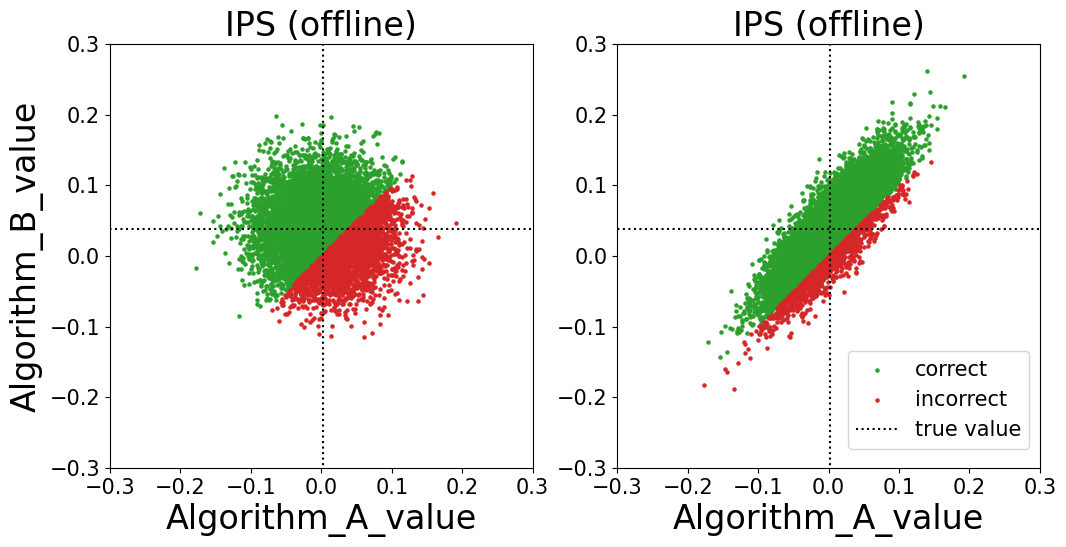

In [17]:
s = 5.0
plt.rcParams["font.size"] = 15
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for idx, est in enumerate(['AVG', 'IPS']):
    mask_mu_rate0 = result_df['mu_rate_0'] == 0.5
    mask_mu_rate1 = result_df['mu_rate_1'] == 0.7
    mask_est = result_df['est'] == est
    mask = mask_mu_rate0 & mask_mu_rate1 & mask_est

    result = result_df[mask].copy().reset_index(drop=True)

    mask_correct = result['selection'] == True
    x = result[mask_correct]['pi_0_value']
    y = result[mask_correct]['pi_1_value']
    axes[idx].scatter(x, y, color='tab:green', label='correct', s=s)

    mask_incorrect = result['selection'] == False
    x = result[mask_incorrect]['pi_0_value']
    y = result[mask_incorrect]['pi_1_value']
    axes[idx].scatter(x, y, color='tab:red', label='incorrect', s=s)

    true_v0 = result['true_pi_0_value'].min()
    true_v1 = result['true_pi_1_value'].max()
    axes[idx].hlines(true_v1, -1.6, 1.6, linestyles='dotted', color='black', label='true value')
    axes[idx].vlines(true_v0, -1.6, 1.6, linestyles='dotted', color='black')

    est = "AVG (A/B test)" if est == "AB_test" else "IPS (offline)"

    axes[idx].set_xlim((-0.3, 0.3))
    axes[idx].set_ylim((-0.3, 0.3))
    axes[idx].set_xlabel('Algorithm_A_value', fontsize=24)
    axes[idx].set_title(f'{est}', fontsize=24)

axes[0].set_ylabel('Algorithm_B_value', fontsize=24)
plt.legend(bbox_to_anchor=(1.0, 0.3))
plt.show()